# Lab 2. Создание и обучение нейросети
## Этапы обучения сети

**Шаг 1.** Сбор датасета.

**Шаг 2.** Создание обучающей и тестовой выборок: обучающий, проверочный (валидационный) и тестовый датасеты.

**Шаг 3.** Определение архитектуры сети, настройка гиперпараметров.

**Шаг 4.** Компиляция модели

**Шаг 5.** Обучение, отслеживание оценки качества НС работы на обучающей и проверочной выборке.

**Шаг 6.** Если результаты предыдущего шага не соответствуют (слишком низкая точность или началось переобучение, см. далее), изменение гиперпараметров, добавление при необходимости слоев нормализации и регуляризации.

**Шаг 7.** Оценка точности работы сети на тестовом наборе.

---

## 1. Создание обучающей (train), проверочной (validation) и тестовой (test) выборки

Имеющийся набор данных делится на три выборки:

1. **Обучающая выборка (training set, x_train)** — используется для обучения сети.
2. **Проверочная выборка (validation set, x_val)** — используется в процессе обучения для оценки качества обучения.
   
   > [!info] Важно
   > Использование проверочной выборки – первый шаг к оценке качества работы НС. Этот набор используется на каждой эпохе обучения. Важно, чтобы данные из проверочной и обучающей выборок **не пересекались и не повторялись**.
   
   Вычленение проверочной части происходит обычно при подаче выборки на обучение, метод `.fit()`, например.

3. **Тестовая выборка (test set, x_test)** — используется для оценки качества работы сети после завершения обучения.

4. Чаще всего ее пропорция следующая: **80% - 15% - 5%** или **80% - 10% - 10%**.

### Создание обучающей и тестовой выборки

Библиотека `sklearn` содержит в себе функцию `train_test_split`, которая согласованно перемешает данные (сохранит соответствие классов и их меток) и выделит выборки в указанном нами процентном соотношении.

In [1]:
# импорт библиотеки
from sklearn.model_selection import train_test_split

**Функция имеет несколько аргументов:**

- `x_data` и `y_data` – разделяемые наборы данных;
- `test_size` – процент значений, которые пойдут в тестовую выборку;
- `shuffle` – требование перемешивания данных. Возможные значения `True` / `False`
- `random_state` – параметр воспроизводимости. Если его указать, то при повторном запуске данные будут перемешаны в том же порядке. Чаще всего используют 0 или 42.

**Функция возвращает:**

- `x_train, x_test, y_train, y_test` – результаты работы функции, обучающая и тестовая выборки.

---

## 2. Создание архитектуры нейронной сети. Подбор гиперпараметров

### Класс создания последовательной модели `Sequential`


In [2]:
from tensorflow.keras.models import Sequential

**Создание экземпляра модели:**

In [3]:
model = Sequential()

### Добавление полносвязного слоя `Dense`

In [4]:
from tensorflow.keras.layers import Dense

# 🟢 ИСПРАВЛЕНО: input_shape вместо input_dim для избежания UserWarning в современных версиях Keras
model.add(Dense(32, input_shape=(10,)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


> [!note] 🟢 ДОБАВЛЕНО: `input_shape` вместо `input_dim`
> В современных версиях Keras рекомендуется использовать `input_shape=(10,)` вместо `input_dim=10`. Это универсальный синтаксис, который в будущем облегчит переход к работе с изображениями (например, `input_shape=(28, 28, 1)`). Однако `input_dim` по-прежнему работает и используется в данной методичке для наглядности.

**Параметр `input_dim`** — размерность входного слоя.

Количество полносвязных нейронов `Dense`-слоя задается первым аргументом (в примере: `32`).

### Оптимизатор и функция потерь

Задаются с помощью метода модели `.compile()`:


In [5]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam')

> [!info] 🟢 ДОБАВЛЕНО: Теория функций активации и потерь
> В коде выше и далее используются специфические параметры. Зачем они нужны?
> - **`activation='relu'`** (для скрытых слоев): Помогает сети обучаться быстрее и бороться с "затуханием градиента".
> - **`activation='softmax'`** (для выходного слоя классификации): Преобразует числа на выходе в вероятности (сумма вероятностей по всем классам равна 1).
> - **`loss='categorical_crossentropy'`**: Стандартная функция потерь для многоклассовой классификации, когда метки переведены в формат One-Hot Encoding.

### Архитектура сети выводится методом `.summary()`

**Пример:**

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352 (1.38 KB)

 Trainable params: 352 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

**Количество параметров сети 352.**

При входе сети из 10 чисел и Dense-слое с 32 нейронами количество весовых коэффициентов будет $10 \times 32 = 320$. Но, как видите, оно получается на 32 больше. Это происходит из-за наличия в слое **нейрона смещения**.

> [!NOTE] Нейроны смещения
> Схематически нейроны смещения обычно не обозначаются, их вес учитывается по умолчанию при работе нейрона.

> [!tip] 🟢 ДОБАВЛЕНО: Как считается количество параметров?
> Формула для слоя `Dense`: `Params = (Input_Size * Neurons) + Neurons`
> При входе из 10 чисел и слое с 32 нейронами: $10 \times 32 = 320$ весов.
> Но в выводе мы видим **352** (на 32 больше). Это происходит из-за наличия в слое **смещения (bias)**. Смещение — это не отдельный "нейрон", а дополнительный обучаемый весовой коэффициент (свободный член уравнения $y = wx + b$), который есть у каждого нейрона.

**Название сети** `"sequential"` автоматически присваивается при создании.

**Колонка `"Output Shape"`** показывает форму данных на выходе нейронного слоя.

В данном случае получается:

1. на вход нейронной сети подается последовательность из 10 элементов (параметр `input_dim`)
2. нейронная сеть состоит из одного слоя (`Dense`), который состоит из 32 нейронов (количество нейронов указано при создании слоя)
3. на выходе нейронной сети будет последовательность из 32 элементов (выход нейронной сети равен выходу последнего слоя)

В выведенной информации вы можете увидеть строку `"Total params: 352"`. В ней указано общее количество параметров модели.

### Параметры

**Параметры модели** – это все веса, внутренние настройки сети, которые определяют, как будет преобразован объект, подаваемый в сеть, прежде чем оказаться на выходе. Они автоматически изменяются при обучении.

**Пример добавления слоев:**


In [7]:
model = Sequential()
model.add(Dense(32, input_dim=10))
model.add(Dense(5))
model.add(Dense(1))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 523 (2.04 KB)

 Trainable params: 523 (2.04 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Компиляция сети. Параметры обучения сети

При обучении нейронной сети обязательно указывают **оптимизатор** и **функцию ошибки**.

**Оптимизатор** — это метод обучения нейронной сети.

Подключается в методе `.compile`:


In [8]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam')

Вы можете либо инициировать оптимизатор перед передачей его в `model.compile()`, как в приведенном выше примере, либо вызвать его по имени. В последнем случае будут использоваться параметры оптимизатора по умолчанию

In [9]:
# при передаче оптимизатора по имени: будут использоваться параметры по умолчанию
model.compile(loss='mean_squared_error', optimizer='sgd')

### Общие для всех оптимизаторов Keras параметры

Параметры `clipnorm` и `clipvalue` могут быть использованы со всеми оптимизаторами для управления градиентной обрезкой:

In [10]:
from keras import optimizers

# Все параметры градиентов будут обрезаны до максимальной нормы от 1.
sgd = optimizers.SGD(learning_rate=0.01, clipnorm=1.)

# Все параметры градиентов будут обрезаны до максимального значения 0.5 и минимального значения -0.5.
sgd = optimizers.SGD(learning_rate=0.01, clipvalue=0.5)

### Оптимизаторы:

1. **SGD** (стохастический градиентный спуск)
2. **Adagrad** (среднеквадратичное распространение корня)
3. **RMSprop** (экспоненциально затухающее среднее)
4. **Adam**

### Импульсный оптимизатор

#### Стохастический градиентный спуск — Stochastic Gradient Descent (SGD)


In [11]:
optimizers.SGD(learning_rate=0.01, momentum=0.0, nesterov=False)

Стохастический оптимизатор градиентного спуска.

Включает в себя поддержку импульса, затухания скорости обучения и импульса Нестерова.

**Аргументы:**

- `learning_rate`: `float >= 0`. Скорость обучения.
- `momentum`: `float >= 0`. Параметр, ускоряющий SGD в соответствующем направлении и гасящий колебания.
- `nesterov`: `boolean`. Применять ли импульс Нестерова?

**Пример использования оптимизатора SGD:**

In [12]:
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, input_shape=(10,), activation='softmax'))

sgd = optimizers.SGD(learning_rate=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(loss='mean_squared_error', optimizer=sgd)

/usr/local/lib/python3.13/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


> [!warning] 🟢 ДОБАВЛЕНО: Устаревший параметр `decay`
> В старых версиях Keras использовался параметр `decay`. В новых версиях TensorFlow/Keras он удалён. Для затухания скорости обучения теперь используется `learning_rate` с расписанием (например, `tf.keras.optimizers.schedules.ExponentialDecay`). В примерах методички параметр `decay` оставлен для совместимости со старыми версиями библиотек.

---

## 4. Обучение сети

In [13]:
import numpy as np

# Создаём новую модель с правильным количеством выходов (10)
model = Sequential()
model.add(Dense(32, input_shape=(10,), activation='relu'))
model.add(Dense(10, activation='softmax'))  # 10 нейронов для 10 классов

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Модель создана. Теперь можно запускать model.fit()")

# Генерация синтетических данных для демонстрации
x_train = np.random.random((1000, 10))  # 1000 примеров, 10 признаков
y_train = np.eye(10)[np.random.randint(0, 10, size=1000)]  # One-hot encoding

history = model.fit(x_train,              # Обучающая выборка
                    y_train,              # Обучающая выборка меток класса
                    batch_size=8,         # Размер батча (пакета)
                    epochs=100,           # Количество эпох обучения
                    validation_split=0.1, # доля проверочной выборки
                    verbose=1)            # Отображение хода обучения

Модель создана. Теперь можно запускать model.fit()
Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0978 - loss: 2.3350 - val_accuracy: 0.1100 - val_loss: 2.3331
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1056 - loss: 2.3116 - val_accuracy: 0.1100 - val_loss: 2.3326
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1111 - loss: 2.3046 - val_accuracy: 0.1100 - val_loss: 2.3369
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1156 - loss: 2.2994 - val_accuracy: 0.1300 - val_loss: 2.3391
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1044 - loss: 2.2949 - val_accuracy: 0.1000 - val_loss: 2.3392
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1322 - loss: 2.2916 - val_accuracy: 0.1100 - val_loss: 2.3427
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1233 - loss: 2.2868 - val_accuracy: 0.1100 - val_loss: 2.3425
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2m


---

## 5. Практическое задание

### Задание 1

Задана модель нейронной сети следующей структуры:

1. `input_dim = 3` — размерность входных данных
2. `Dense(3)` — первый полносвязный слой с тремя нейронами
3. `Dense(1)` — второй полносвязный слой с одним нейроном.

**Создайте модель заданной структуры, для этого:**

1. импортируйте библиотеку для создания модели
2. импортируйте библиотеку для создания необходимых слоев
3. создайте модель полносвязной сети
4. добавьте заданные слои в модель.

**Выведите структуру модели с помощью функции `.summary()`.**

In [6]:
import tensorflow as tf

# # 1. Импортируем библиотеку для создания модели
# from tensorflow.keras.models import Sequential

# # 2. Импортируем библиотеку для создания необходимых слоёв
# from tensorflow.keras.layers import Dense

# 3. Создаем модель полносвязной сети
model = tf.keras.models.Sequential()

# 4. Добавляем заданные слои в модель
model.add(tf.keras.layers.Dense(3, input_dim=3))
model.add(tf.keras.layers.Dense(1))

# Выводим структуру модели
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Вывод весов модели
for layer in model.layers:
    print(f"Слой: {layer.name}")
    print("Веса:", layer.get_weights())
    print("-" * 20)

Слой: dense_6
Веса: [array([[-0.45586705, -0.58463883, -0.9363053 ],
       [ 0.72065806,  0.01630092, -0.9611006 ],
       [-0.05864763,  0.5155976 ,  0.8625295 ]], dtype=float32), array([0., 0., 0.], dtype=float32)]
--------------------
Слой: dense_7
Веса: [array([[-0.6490996 ],
       [-0.6331545 ],
       [-0.00885355]], dtype=float32), array([0.], dtype=float32)]
--------------------




### Задание 2

Создайте такую же нейронную сеть, как в первом задании, отключив нейрон смещения — параметр `use_bias=False`, используемый при создании полносвязного слоя. **Выведите структуру модели и веса. Посмотрите, что изменилось.**


In [3]:
12import tensorflow as tf

# Создаем модель
model_no_bias = tf.keras.models.Sequential()

# Добавляем слои отключив нейрон смещения
model_no_bias.add(tf.keras.layers.Dense(3, input_dim=3, use_bias=False))
model_no_bias.add(tf.keras.layers.Dense(1, use_bias=False))

# Вывгодим структуру нейрона
model_no_bias.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Вывод весов модели
for layer in model_no_bias.layers:
    print(f"Слой: {layer.name}")
    print("Веса:", layer.get_weights())
    print("-" * 20)

Слой: dense_4
Веса: [array([[ 0.7097206 , -0.03772402, -0.80132985],
       [-0.41873407,  0.75606155,  0.8467486 ],
       [ 0.48062468,  0.19069457, -0.48892856]], dtype=float32)]
--------------------
Слой: dense_5
Веса: [array([[ 0.23347926],
       [-1.1083418 ],
       [ 0.7367667 ]], dtype=float32)]
--------------------



---

## Практическое задание

### Задание 1. Распознавание рукописных цифр MNIST

**Создайте свою архитектуру нейронной сети для классификации рукописных цифр.**

1. Обучите сеть
2. Выведите структуру модели с помощью функции `.summary()`.
3. Выведите графики ошибки
4. Проверьте работу сети на любом примере.

### Задание 2. Определение цифр на реальных фотографиях

1. Нарисуйте цифры, загрузите, переведите в формат для подачи в нейронную сети.
2. Создайте собственную архитектуру сверточной нейронной сети для распознавания цифр на базе рукописных цифр MNIST.
3. Обучите сеть и выведите результаты
4. Оцените результаты работы сети на собственных цифрах.

> [!tip] 🟢 ДОБАВЛЕНО: Примечание про сверточные сети
> *Примечание для студентов: В данной лабораторной мы работаем с классическими полносвязными сетями (`Dense`). Сверточные нейронные сети (CNN), которые лучше подходят для работы с изображениями, мы будем создавать и изучать в следующей лабораторной работе. Если вы ещё не проходили CNN, в Задании 2 достаточно использовать архитектуру из Задания 1, изменив количество слоёв и нейронов.*




---

## Вспомогательный материал

### Пример. Распознавание рукописных цифр MNIST

#### Подготовка данных

**Необходимые модули:**

1. `mnist` – модуль для загрузки набора данных рукописных цифр, который вы используете при обучении нейронной сети;
2. `Sequential` – модуль для создания последовательной модели нейронной сети;
3. `Dense` – линейный (полносвязный) слой. Из таких слоев будет создана ваша нейросеть;
4. `utils` – модуль с полезными инструментами для подготовки данных;
5. `plt` – модуль рисования графиков.


In [9]:
from tensorflow.keras.datasets import mnist     # Библиотека с базой рукописных цифр
from tensorflow.keras.models import Sequential  # Подключение класса создания модели Sequential
from tensorflow.keras.layers import Dense       # Подключение класса Dense - полносвязный слой
from tensorflow.keras import utils              # Утилиты для подготовки данных
import numpy as np                              # Работа с массивами
import matplotlib.pyplot as plt                 # Отрисовка изображений

# Отрисовка изображений в ячейках ноутбука
%matplotlib inline

**Набор данных** это набор картинок, на которых изображены рукописные цифры от 0 до 9.

`x_train_org`, `y_train_org` – изображения для обучения нейронной сети;

`x_test_org`, `y_test_org` – изображения для тестирования нейронной сети.

In [10]:
# Загрузка из облака данных Mnist
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Набор данных представляет** — матрицы чисел, где каждое число – это значение яркости пиксела (от 0 до 255). В тренировочном наборе данных 60000, размер 28 на 28 пикс.

In [11]:
# Вывод формы данных для обучения
x_train_org.shape

(60000, 28, 28)

#### Вывод картинки

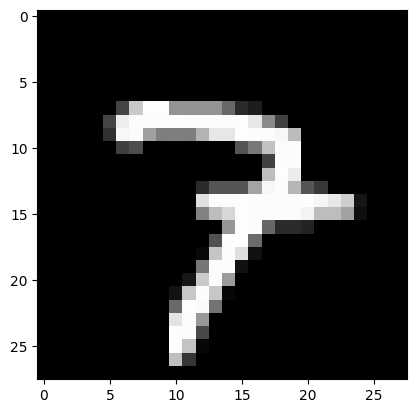

7


In [25]:
# Номер картинки
n = 3214

# Отрисовка картинки
plt.imshow(x_train_org[n], cmap='gray')

# Вывод n-й картинки
plt.show()

# Вывод метки класса для n-го изображения
print(y_train_org[n])

#### Преобразуем в одномерную последовательность чисел (вектор) с помощью метода `.reshape()`:

In [18]:
# Изменение формы с 28х28 на 784
x_train = x_train_org.reshape(x_train_org.shape[0], -1)
x_test = x_test_org.reshape(x_test_org.shape[0], -1)

# Проверка результата
print(f'Форма обучающих данных: {x_train_org.shape} -> {x_train.shape}')
print(f'Форма тестовых данных: {x_test_org.shape} -> {x_test.shape}')

Форма обучающих данных: (60000, 28, 28) -> (60000, 784)
Форма тестовых данных: (10000, 28, 28) -> (10000, 784)


**Теперь каждая картинка представлена последовательностью из 784 чисел (28x28).** Это сглаженные данные изображения, которые извлекаются из `mnist.train.nextbatch()`.

In [19]:
# Нормализация входных картинок
# Преобразование x_train в тип float32 (числа с плавающей точкой) и нормализация
x_train = x_train.astype('float32') / 255.

# Преобразование x_test в тип float32 (числа с плавающей точкой) и нормализация
x_test = x_test.astype('float32') / 255.

# Задание константы количества распознаваемых классов
CLASS_COUNT = 10

# Преобразование y в формат one_hot_encoding
y_train = utils.to_categorical(y_train_org, CLASS_COUNT)
y_test = utils.to_categorical(y_test_org, CLASS_COUNT)

# Вывод формы y_train
# 60 тысяч примеров, каждый длины 10 по числу классов
print(y_train.shape)

# Вывод примера одного выходного вектора
print(y_train[0])

(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [20]:
# Вывод формы массива меток
print(y_train_org.shape)

# Вывод метки, соответствующей 36-му элементу
print(y_train_org[36])

(60000,)
6


#### Создание нейронной сети

In [21]:
# Создание последовательной модели
model = Sequential()

# Добавление полносвязного слоя на 800 нейронов с relu-активацией
model.add(Dense(800, input_dim=784, activation='relu'))

# Добавление полносвязного слоя на 400 нейронов с relu-активацией
model.add(Dense(400, activation='relu'))

# Добавление полносвязного слоя с количеством нейронов по числу классов с softmax-активацией
model.add(Dense(CLASS_COUNT, activation='softmax'))

#### Компиляция модели

In [22]:
# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Вывод структуры модели
print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 400)            │       320,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 952,410 (3.63 MB)

 Trainable params: 952,410 (3.63 MB)

 Non-trainable params: 0 (0.00 B)

None


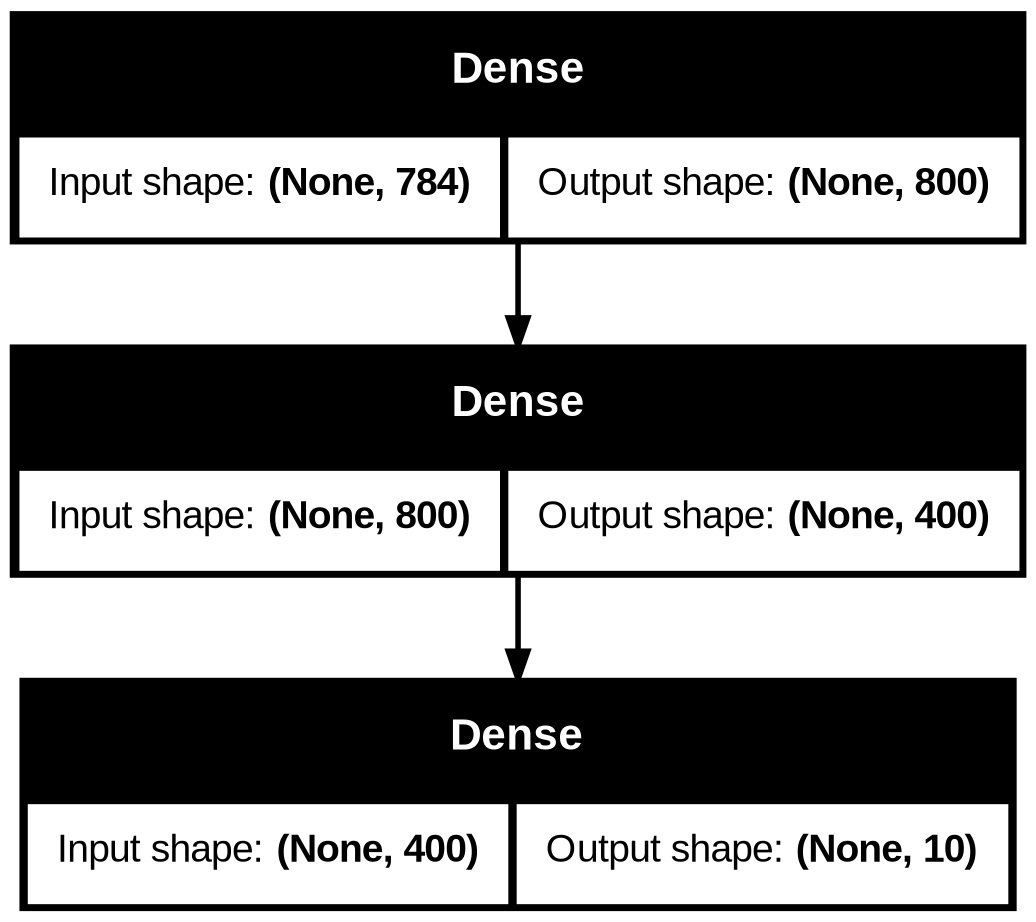

In [23]:
utils.plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=False)


> [!NOTE] Сохранение графа модели
> Сохранение графа модели произойдёт в хранилище виртуальной машины ноутбука.
>
> Для сохранения файла подключить гугл диск:
> ```python
> from google.colab import drive
> drive.mount('/content/drive/')
> ```
> Необходимо перейти по ссылке и разрешить доступ.
> Теперь данные могут быть загружены на диск, необходимо указывать полный путь для сохранения.

#### Обучение нейронной сети

**Метод модели `.fit()`**, данные для обучения — `x_train`, `y_train`:

In [24]:
model.fit(x_train, y_train, batch_size=128, epochs=15, verbose=1)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9401 - loss: 0.2024
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9758 - loss: 0.0757
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9849 - loss: 0.0475
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9885 - loss: 0.0347
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9917 - loss: 0.0253
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9936 - loss: 0.0194
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9929 - loss: 0.0213
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9951 - loss: 0.0144
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9952 - loss: 0.0147
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9963 - loss: 0.0107
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9950 - loss: 0.0156
Epoch 12/15
469/469 ━━━━━━━━━━━━━

- `batch_size` – размер батча, который указывает нейросети на то, сколько картинок она будет обрабатывать за один раз.
- `epochs` – количество эпох.

In [25]:
# model.fit(x_train,        # обучающая выборка, входные данные
#           y_train,        # обучающая выборка, выходные данные
#           batch_size=128, # размер батча
#           epochs=15,      # количество эпох,
#           verbose=1)      # 0 - не визуализировать ход обучения, 1 - визуализировать

#### Сохранить веса модели

In [26]:
# ✅ Сохраняет архитектуру + веса + состояние оптимизатора в одном файле
model.save('mnist_model.keras')

Метод `.save_weights()` сохранит веса модели в хранилище, а метод `.load_weights()` загрузит их обратно.

> [!note] 🟢 ДОБАВЛЕНО: Современный формат сохранения
> В новых версиях TensorFlow формат `.h5` для сохранения моделей считается устаревшим. Рекомендуется использовать новый формат `.keras`:
> ```python
> # Сохранение всей модели целиком (архитектура + веса + оптимизатор)
> model.save('mnist_model.keras')
>
> # Загрузка модели
> from tensorflow.keras.models import load_model
> model = load_model('mnist_model.keras')
> ```

#### Распознавание рукописных цифр

**Вывести на экран какой-нибудь образец из тестового набора данных:**

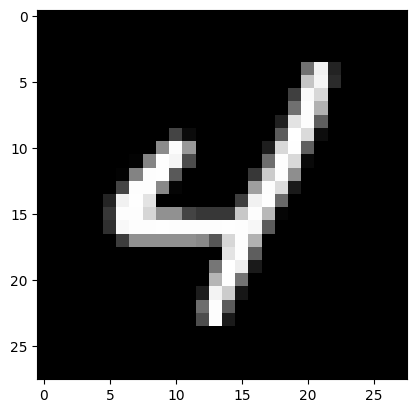

(784,)


In [27]:
# Номер тестовой цифры
n_rec = np.random.randint(x_test_org.shape[0])

# Отображение картинки из тестового набора под номером n_rec
plt.imshow(x_test_org[n_rec], cmap='gray')
plt.show()

# Выбор нужной картинки из тестовой выборки
x = x_test[n_rec]

# Проверка формы данных
print(x.shape)

In [28]:
# Добавление одной оси.
# Массив из одного примера,
x = np.expand_dims(x, axis=0)

# Проверка формы данных
print(x.shape)

(1, 784)


#### Запуск сети

**Метод `.predict()`**

Передать в метод данные для распознавания:

In [29]:
# Распознавание примера
prediction = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


**Ответ нейронной сети:**

In [30]:
# Вывод результата - вектор из 10 чисел
print(prediction)

[[8.5472143e-18 2.2536523e-10 5.4831348e-12 1.6208382e-17 1.0000000e+00
  4.0936760e-14 5.7828200e-13 2.0706683e-14 1.0003859e-14 1.8870821e-13]]


> [!tip] 🟢 ДОБАВЛЕНО: Получение итоговой цифры
> Сеть выдаёт массив из 10 вероятностей. Чтобы получить саму распознанную цифру, используйте `np.argmax`:
> ```python
> print("Распознанная цифра:", np.argmax(prediction))
> print("Истинная цифра:", y_test_org[n_rec])
> ```

---

## 6. Визуализация качества обучения

Создадим примитивную сеть и обучим ее на наборе MNIST:

In [31]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# ------

from tensorflow.keras.datasets import mnist # загрузка всего датасет MNIST
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

x_train = x_train_org.reshape(x_train_org.shape[0], -1)
x_test = x_test_org.reshape(x_test_org.shape[0], -1)

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

from tensorflow.keras import utils
y_train = utils.to_categorical(y_train_org, 10)
y_test = utils.to_categorical(y_test_org, 10)

# ------

# Создание модели
model = Sequential()

# Добавление слоев
model.add(Dense(800, input_dim=784, activation='relu'))
model.add(Dense(400, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Компиляция и возврат модели
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Запишем результат обучения в переменную, запишем `history = model.fit()`:**

In [32]:
history = model.fit(x_train,              # Обучающая выборка
                    y_train,              # Обучающая выборка меток класса
                    batch_size=256,       # Размер батча (пакета)
                    epochs=100,           # Количество эпох обучения
                    validation_split=0.1, # доля проверочной выборки
                    verbose=1)            # Отображение хода обучения

Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9237 - loss: 0.2630 - val_accuracy: 0.9712 - val_loss: 0.1011
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9727 - loss: 0.0904 - val_accuracy: 0.9760 - val_loss: 0.0769
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9835 - loss: 0.0531 - val_accuracy: 0.9752 - val_loss: 0.0783
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9883 - loss: 0.0387 - val_accuracy: 0.9778 - val_loss: 0.0771
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9926 - loss: 0.0239 - val_accuracy: 0.9823 - val_loss: 0.0660
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9940 - loss: 0.0179 - val_accuracy: 0.9818 - val_loss: 0.0650
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9968 - loss: 0.0111 - val_accuracy: 0.9827 - val_loss: 0.0729
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9968 - loss: 0.0098

In [33]:
print(type(history.history))

<class 'dict'>


**Это словарь, посмотрим ключи:**

In [34]:
#dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


- `'loss'` — значения ошибки на обучающей выборке
- `'accuracy'` — точность на обучающей выборке
- `'val_loss'` — значения ошибки на проверочной выборке
- `'val_accuracy'` — точность на проверочной выборке

К данным можно обращаться и выводить, как и с обычным словарем:

In [35]:
# Вывод значений ошибки (loss) на обучающей выборке
print(history.history['loss'][:5])

# Вывод значений точности распознавания (loss) на проверочной выборке
print(history.history['val_accuracy'][:5])

# Вывод значения точности распознавания на проверочной выборке по эпохам
val_acc = history.history['val_accuracy']

for i in range(5):
    # .format() - метод форматирования данных при выводе
    print('Эпоха: {:2} точность: {:5.1%}'.format(i, val_acc[i]))

[0.2630324363708496, 0.09040517359972, 0.05308830365538597, 0.03871167078614235, 0.023919735103845596]
[0.9711666703224182, 0.9760000109672546, 0.9751666784286499, 0.9778333306312561, 0.9823333621025085]
Эпоха:  0 точность: 97.1%
Эпоха:  1 точность: 97.6%
Эпоха:  2 точность: 97.5%
Эпоха:  3 точность: 97.8%
Эпоха:  4 точность: 98.2%


**Построим графики точности на обучающей и проверочной выборках на протяжении всего обучения:**

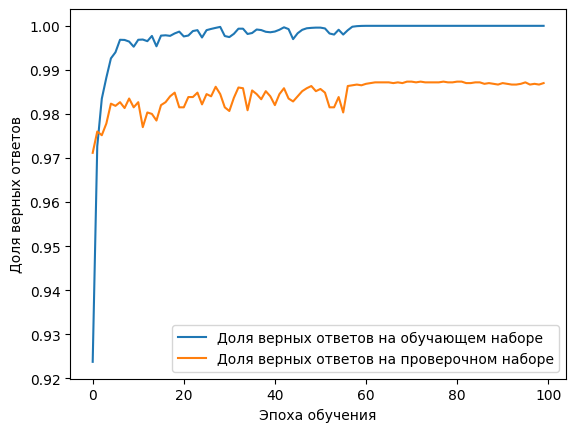

In [36]:
# Рисование графиков
import matplotlib.pyplot as plt

# Отрисовка графика точности на обучающей выборке
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')

# Отрисовка графика точности на проверочной выборке
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')

# Отрисовка подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')

# Отрисовка легенды
plt.legend()

# Вывод графика
plt.show()

**Построим графики ошибки:**

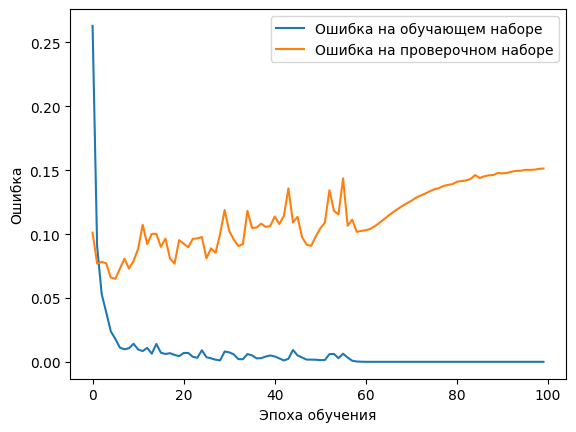

In [37]:
plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')

plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')

plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')

plt.legend()

plt.show()

> [!warning] 🟢 ДОБАВЛЕНО: Как заметить переобучение (Overfitting) на графиках?
> Переобучение возникает, когда сеть "запоминает" обучающую выборку, но не умеет работать с новыми данными.
> **Как это выглядит на графиках:**
> - **Ошибка (Loss):** Линия `loss` (обучение) продолжает падать, а линия `val_loss` (проверка) начинает **расти**.
> - **Точность (Accuracy):** Линия `accuracy` (обучение) стремится к 100%, а линия `val_accuracy` (проверка) останавливается и начинает **снижаться** или "дрожать".
>
> *Если вы увидели это на графиках, значит, нужно остановить обучение (или уменьшить количество `epochs`), либо упростить архитектуру сети, либо добавить Dropout/BatchNormalization.*
---
